# File 4 — Hybrid Model: Feature + Embedding Comparison

## Overview

Combines CodeBERT embeddings with feature embedding(hand-crafted) to test whether hybrid representations outperform either approach alone.




## 0. Install Dependencies

In [1]:
!pip install -q datasets xgboost imbalanced-learn transformers accelerate

## 1. Imports & Setup

In [2]:
import ast, os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier
from sklearn.pipeline           import Pipeline
from sklearn.preprocessing      import StandardScaler
from sklearn.model_selection    import train_test_split
from sklearn.metrics            import (f1_score, accuracy_score,
                                        confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost                    import XGBClassifier

warnings.filterwarnings("ignore")

FIGS  = "/content/figures";  os.makedirs(FIGS,  exist_ok=True)
RSLTS = "/content/results";  os.makedirs(RSLTS, exist_ok=True)

PALETTE = ["#2E4057", "#048A81", "#54C6EB", "#EF946C", "#C4A35A", "#A23B72"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({"figure.dpi": 140, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})
print("Imports done.")


Imports done.


## 2. Configuration

In [3]:
# Trial vs Full run
TRIAL_RUN = False         # set False for full run
SAMPLES   = 2000 if TRIAL_RUN else None

if TRIAL_RUN:
    print("*** TRIAL RUN — 2000 rows only ***")
    print("Set TRIAL_RUN = False for the full run.")
else:
    print("FULL RUN — loading entire dataset")


FORCE_RERUN = False   # set True to ignore all cache and rerun fresh
# Data
HF_DATASET = "HuggingFaceTB/python-edu-annotations"

# File 3 embeddings path
# Points directly to embeddings saved by File 3
FILE3_EMBED_PATH = "/content/drive/MyDrive/codebert_file3/main_embeddings.npz"

#File 4 cache directory
DRIVE_CACHE = "/content/drive/MyDrive/file4_cache"
if TRIAL_RUN:
    DRIVE_CACHE += "_trial"

print(f"File 3 embeddings : {FILE3_EMBED_PATH}")
print(f"File 4 cache      : {DRIVE_CACHE}")


FULL RUN — loading entire dataset
File 3 embeddings : /content/drive/MyDrive/codebert_file3/main_embeddings.npz
File 4 cache      : /content/drive/MyDrive/file4_cache


## 3. Mount Google Drive

In [4]:
from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_CACHE, exist_ok=True)
print(f"Drive mounted.")
print(f"Cache dir  : {DRIVE_CACHE}")
print(f"FORCE_RERUN: {FORCE_RERUN}")


Mounted at /content/drive
Drive mounted.
Cache dir  : /content/drive/MyDrive/file4_cache
FORCE_RERUN: False


## 4. Cache Helpers

In [5]:
def cache_path(name):
    return os.path.join(DRIVE_CACHE, name)

def save_npz(name, **arrays):
    path = cache_path(name)
    np.savez_compressed(path, **arrays)
    print(f"  Saved  -> {path}")

def load_npz(name):
    path = cache_path(name)
    data = np.load(path, allow_pickle=True)
    print(f"  Loaded <- {path}")
    return data

def save_json(name, obj):
    path = cache_path(name)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"  Saved  -> {path}")

def load_json(name):
    path = cache_path(name)
    with open(path) as f:
        obj = json.load(f)
    print(f"  Loaded <- {path}")
    return obj

def is_cached(name):
    return (not FORCE_RERUN) and os.path.exists(cache_path(name))


## 5. Feature Definitions

In [6]:
doc_features = ["num_comments", "comment_ratio", "has_docstring"]

lexical_features = [
    "num_lines", "avg_line_length",
    "indentation_depth", "has_input_output",
]

syntactic_features = [
    "num_functions", "num_loops", "num_if_statements",
    "total_ast_nodes", "has_main_block",
]

all_features = doc_features + lexical_features + syntactic_features

print(f"doc_features      ({len(doc_features)})  : {doc_features}")
print(f"lexical_features  ({len(lexical_features)})  : {lexical_features}")
print(f"syntactic_features({len(syntactic_features)})  : {syntactic_features}")
print(f"all_features      ({len(all_features)}) : {all_features}")


doc_features      (3)  : ['num_comments', 'comment_ratio', 'has_docstring']
lexical_features  (4)  : ['num_lines', 'avg_line_length', 'indentation_depth', 'has_input_output']
syntactic_features(5)  : ['num_functions', 'num_loops', 'num_if_statements', 'total_ast_nodes', 'has_main_block']
all_features      (12) : ['num_comments', 'comment_ratio', 'has_docstring', 'num_lines', 'avg_line_length', 'indentation_depth', 'has_input_output', 'num_functions', 'num_loops', 'num_if_statements', 'total_ast_nodes', 'has_main_block']


## 6. Load Dataset

In [7]:
def extract_code_from_prompt(text: str) -> str:
    if "The extract:" not in text:
        return ""
    code = text.split("The extract:")[-1]
    for marker in ("After examining the extract:", "Educational score:"):
        if marker in code:
            code = code.split(marker)[0]
    return code.strip()


In [ ]:
DF_CACHE = "dataframe.npz"

if is_cached(DF_CACHE):
    print("Loading dataset from Drive cache...")
    cache  = load_npz(DF_CACHE)
    df     = pd.DataFrame({"code": cache["codes"].tolist(),
                           "score": cache["scores"].tolist()})
else:
    from datasets import load_dataset
    print(f"Loading '{HF_DATASET}' from HuggingFace...")
    ds = load_dataset(HF_DATASET, split="train", streaming=True)
    rows = []
    for i, ex in enumerate(ds):
        if SAMPLES and i >= SAMPLES:
            break
        rows.append(ex)
        if (i + 1) % 5000 == 0:
            print(f"  {i+1:,} rows loaded...", flush=True)
    df = pd.DataFrame(rows)
    df["code"]  = df["prompt"].apply(extract_code_from_prompt)
    df          = df.dropna(subset=["score", "code"])
    df["score"] = df["score"].astype(int)
    df          = df[df["score"].between(1, 5) & (df["code"].str.len() >= 20)]
    df          = df.reset_index(drop=True)
    save_npz(DF_CACHE,
             codes=np.array(df["code"].tolist()),
             scores=np.array(df["score"].tolist()))

print(f"Dataset: {df.shape}")
print(df["score"].value_counts().sort_index().rename("count").to_frame())


## 7. Train / Val / Test Split (70 / 15 / 15)

In [9]:
SPLIT_CACHE = "splits.npz"

if is_cached(SPLIT_CACHE):
    print("Loading splits from Drive cache...")
    cache    = load_npz(SPLIT_CACHE)
    df_train = df.iloc[cache["tr_idx"]].reset_index(drop=True)
    df_val   = df.iloc[cache["va_idx"]].reset_index(drop=True)
    df_test  = df.iloc[cache["te_idx"]].reset_index(drop=True)
else:
    df_train, df_temp = train_test_split(
        df, test_size=0.30, stratify=df["score"], random_state=42
    )
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, stratify=df_temp["score"], random_state=42
    )
    save_npz(SPLIT_CACHE,
             tr_idx=np.array(df_train.index),
             va_idx=np.array(df_val.index),
             te_idx=np.array(df_test.index))
    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

y_tr = df_train["score"].values
y_va = df_val["score"].values
y_te = df_test["score"].values

print(f"Train : {len(df_train):,}  (70%)")
print(f"Val   : {len(df_val):,}   (15%)")
print(f"Test  : {len(df_test):,}  (15%)")


  Saved  -> /content/drive/MyDrive/file4_cache/splits.npz
Train : 343,644  (70%)
Val   : 73,638   (15%)
Test  : 73,639  (15%)


## 8. Feature Extraction

In [10]:
def get_features(code: str) -> dict:
    features: dict = {}
    try:
        tree = ast.parse(code)
        features["total_ast_nodes"]   = len(list(ast.walk(tree)))
        features["num_functions"]     = sum(isinstance(n, ast.FunctionDef) for n in ast.walk(tree))
        features["num_loops"]         = sum(isinstance(n, (ast.For, ast.While)) for n in ast.walk(tree))
        features["num_if_statements"] = sum(isinstance(n, ast.If) for n in ast.walk(tree))
        features["has_main_block"]    = int("__name__" in code)
        features["has_docstring"]     = int(ast.get_docstring(tree) is not None)
    except SyntaxError:
        features.update({"total_ast_nodes": 0, "num_functions": 0, "num_loops": 0,
                         "num_if_statements": 0, "has_docstring": 0, "has_main_block": 0})
    lines     = code.split("\n")
    num_lines = len(lines)
    denom     = max(1, num_lines)
    features["num_lines"]         = num_lines
    features["num_comments"]      = sum(1 for l in lines if "#" in l)
    features["comment_ratio"]     = features["num_comments"] / denom
    features["avg_line_length"]   = sum(len(l) for l in lines) / denom
    features["indentation_depth"] = (max((len(l) - len(l.lstrip())) for l in lines if l.strip())
                                     if any(l.strip() for l in lines) else 0)
    features["has_input_output"]  = int("input(" in code or "print(" in code)
    return features

def extract_subset(split_df, feature_list):
    rows = []
    for c in split_df["code"]:
        full = get_features(c)
        rows.append({k: v for k, v in full.items() if k in feature_list})
    return pd.DataFrame(rows).fillna(0.0).values


In [11]:
FEAT_CACHE = "features_all.npz"

if is_cached(FEAT_CACHE):
    print("Loading feature matrices from Drive cache...")
    cache    = load_npz(FEAT_CACHE)
    X_fo_tr  = cache["X_fo_tr"]
    X_fo_te  = cache["X_fo_te"]
    X_lex_tr = cache["X_lex_tr"]
    X_lex_te = cache["X_lex_te"]
    X_syn_tr = cache["X_syn_tr"]
    X_syn_te = cache["X_syn_te"]
    X_doc_tr = cache["X_doc_tr"]
    X_doc_te = cache["X_doc_te"]
else:
    print("Extracting feature matrices...")
    X_fo_tr  = extract_subset(df_train, all_features);       X_fo_te  = extract_subset(df_test, all_features)
    X_lex_tr = extract_subset(df_train, lexical_features);   X_lex_te = extract_subset(df_test, lexical_features)
    X_syn_tr = extract_subset(df_train, syntactic_features); X_syn_te = extract_subset(df_test, syntactic_features)
    X_doc_tr = extract_subset(df_train, doc_features);       X_doc_te = extract_subset(df_test, doc_features)
    save_npz(FEAT_CACHE,
             X_fo_tr=X_fo_tr,   X_fo_te=X_fo_te,
             X_lex_tr=X_lex_tr, X_lex_te=X_lex_te,
             X_syn_tr=X_syn_tr, X_syn_te=X_syn_te,
             X_doc_tr=X_doc_tr, X_doc_te=X_doc_te)

print(f"Feature-Only      : train={X_fo_tr.shape}  test={X_fo_te.shape}")
print(f"Lexical           : train={X_lex_tr.shape}  test={X_lex_te.shape}")
print(f"Syntactic         : train={X_syn_tr.shape}  test={X_syn_te.shape}")
print(f"Doc               : train={X_doc_tr.shape}  test={X_doc_te.shape}")


Extracting feature matrices...
  Saved  -> /content/drive/MyDrive/file4_cache/features_all.npz
Feature-Only      : train=(343644, 12)  test=(73639, 12)
Lexical           : train=(343644, 4)  test=(73639, 4)
Syntactic         : train=(343644, 5)  test=(73639, 5)
Doc               : train=(343644, 3)  test=(73639, 3)


## 9. Load CodeBERT Embeddings (from File 3)

Loading directly from File 3's cache.
pooling=cls, max_len=256 (best config from File 2).


In [12]:
print(f"Loading embeddings from: {FILE3_EMBED_PATH}")

if not os.path.exists(FILE3_EMBED_PATH):
    raise FileNotFoundError(
        f"File 3 embeddings not found at {FILE3_EMBED_PATH}\n"
        "Please run File 3 first to generate and cache the embeddings."
    )

emb_cache = np.load(FILE3_EMBED_PATH)
X_emb_tr  = emb_cache["X_emb_tr"]
X_emb_te  = emb_cache["X_emb_te"]

print(f"Train embeddings : {X_emb_tr.shape}")
print(f"Test  embeddings : {X_emb_te.shape}")


Loading embeddings from: /content/drive/MyDrive/codebert_file3/main_embeddings.npz
Train embeddings : (343644, 768)
Test  embeddings : (73639, 768)


## 10. Build Hybrid Feature Matrices

Each hybrid tier = CodeBERT embeddings concatenated with a feature subset.


In [13]:
# Concatenate embeddings with each feature group
X_hyb_lex_tr = np.hstack([X_emb_tr, X_lex_tr]);  X_hyb_lex_te = np.hstack([X_emb_te, X_lex_te])
X_hyb_syn_tr = np.hstack([X_emb_tr, X_syn_tr]);  X_hyb_syn_te = np.hstack([X_emb_te, X_syn_te])
X_hyb_doc_tr = np.hstack([X_emb_tr, X_doc_tr]);  X_hyb_doc_te = np.hstack([X_emb_te, X_doc_te])
X_hyb_all_tr = np.hstack([X_emb_tr, X_fo_tr]);   X_hyb_all_te = np.hstack([X_emb_te, X_fo_te])

print("Hybrid matrix dimensions:")
print(f"  Hybrid (Lexical)   : train={X_hyb_lex_tr.shape}  test={X_hyb_lex_te.shape}")
print(f"  Hybrid (Syntactic) : train={X_hyb_syn_tr.shape}  test={X_hyb_syn_te.shape}")
print(f"  Hybrid (Doc)       : train={X_hyb_doc_tr.shape}  test={X_hyb_doc_te.shape}")
print(f"  Hybrid (ALL)       : train={X_hyb_all_tr.shape}  test={X_hyb_all_te.shape}")


Hybrid matrix dimensions:
  Hybrid (Lexical)   : train=(343644, 772)  test=(73639, 772)
  Hybrid (Syntactic) : train=(343644, 773)  test=(73639, 773)
  Hybrid (Doc)       : train=(343644, 771)  test=(73639, 771)
  Hybrid (ALL)       : train=(343644, 780)  test=(73639, 780)


## 11. Define All Six Tiers

In [14]:
TIERS = {
    "1. Feature-Only":      (X_fo_tr,      X_fo_te),
    "2. Embedding-Only":    (X_emb_tr,     X_emb_te),
    "3. Hybrid (Lexical)":  (X_hyb_lex_tr, X_hyb_lex_te),
    "4. Hybrid (Syntactic)":(X_hyb_syn_tr, X_hyb_syn_te),
    "5. Hybrid (Doc)":      (X_hyb_doc_tr, X_hyb_doc_te),
    "6. Hybrid (ALL)":      (X_hyb_all_tr, X_hyb_all_te),
}

TIER_DIMS = {
    "1. Feature-Only":       12,
    "2. Embedding-Only":    768,
    "3. Hybrid (Lexical)":  772,
    "4. Hybrid (Syntactic)":773,
    "5. Hybrid (Doc)":      771,
    "6. Hybrid (ALL)":      780,
}

print("Tiers registered:")
for name, (Xtr, Xte) in TIERS.items():
    print(f"  {name:<28}  dim={Xtr.shape[1]:>4}  "
          f"train={Xtr.shape[0]:,}  test={Xte.shape[0]:,}")


Tiers registered:
  1. Feature-Only               dim=  12  train=343,644  test=73,639
  2. Embedding-Only             dim= 768  train=343,644  test=73,639
  3. Hybrid (Lexical)           dim= 772  train=343,644  test=73,639
  4. Hybrid (Syntactic)         dim= 773  train=343,644  test=73,639
  5. Hybrid (Doc)               dim= 771  train=343,644  test=73,639
  6. Hybrid (ALL)               dim= 780  train=343,644  test=73,639


## 12. Classifiers & Evaluation Helpers

In [15]:
def build_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42)),
    ])

def build_rf(class_weight="balanced"):
    return RandomForestClassifier(
        n_estimators=150, class_weight=class_weight, random_state=42, n_jobs=-1
    )

def build_xgb():
    return XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softmax", num_class=5,
        eval_metric="mlogloss", tree_method="hist",
        n_jobs=-1, random_state=42, verbosity=0,
    )

CLASSIFIERS = {
    "LogisticRegression": build_logreg,
    "RandomForest":       build_rf,
    "XGBoost":            build_xgb,
}

def fit_predict(clf_name, X_tr, y_tr, X_te):
    if clf_name == "XGBoost":
        clf = build_xgb()
        sw  = compute_sample_weight("balanced", y=y_tr)
        clf.fit(X_tr, y_tr - 1, sample_weight=sw)
        return clf.predict(X_te) + 1, clf
    clf = CLASSIFIERS[clf_name]()
    clf.fit(X_tr, y_tr)
    return clf.predict(X_te), clf

def full_eval(y_true, y_pred):
    return {
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 4),
        "macro_f1": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
        "cm":       confusion_matrix(y_true, y_pred).tolist(),
        "report":   classification_report(y_true, y_pred, zero_division=0, output_dict=True),
    }


## 13. Plotting Helpers

In [16]:
def savefig(name):
    path = os.path.join(FIGS, name)
    plt.savefig(path)
    plt.show()
    plt.close()
    print(f"  saved -> {path}")

def plot_cm(cm_list, title, fname):
    cm   = np.array(cm_list)
    norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ax, data, fmt, sub in zip(axes, [cm, norm], ["d", ".2f"], ["Counts", "Row-normalised"]):
        sns.heatmap(data, annot=True, fmt=fmt, ax=ax, cmap="Blues",
                    xticklabels=range(1,6), yticklabels=range(1,6),
                    linewidths=.4, cbar_kws={"shrink":.8})
        ax.set_xlabel("Predicted Score"); ax.set_ylabel("True Score")
        ax.set_title(sub)
    plt.tight_layout()
    savefig(fname)


## 14. Run All Tiers (Test Set)

Trains LR / RF / XGBoost on every tier and records accuracy + macro-F1.


In [17]:
ALL_RESULTS_CACHE = "all_tier_results.json"

if is_cached(ALL_RESULTS_CACHE):
    print("Loading all tier results from Drive cache...")
    all_tier_results = load_json(ALL_RESULTS_CACHE)
    print(f"  Loaded {len(all_tier_results)} results.")
else:
    all_tier_results = []
    print(f"{'Tier':<28} {'Model':<22} {'Accuracy':>10} {'Macro-F1':>10}")
    print("-" * 74)
    for tier_name, (X_tr, X_te) in TIERS.items():
        for clf_name in CLASSIFIERS:
            y_pred, _ = fit_predict(clf_name, X_tr, y_tr, X_te)
            m = full_eval(y_te, y_pred)
            m["tier"]  = tier_name
            m["model"] = clf_name
            m["dim"]   = TIER_DIMS[tier_name]
            all_tier_results.append(m)
            print(f"  {tier_name:<26} {clf_name:<22} "
                  f"{m['accuracy']:>10.4f} {m['macro_f1']:>10.4f}")
    save_json(ALL_RESULTS_CACHE, all_tier_results)

print("\nDone!")


Tier                         Model                    Accuracy   Macro-F1
--------------------------------------------------------------------------
  1. Feature-Only            LogisticRegression         0.3647     0.2934
  1. Feature-Only            RandomForest               0.4609     0.3497
  1. Feature-Only            XGBoost                    0.4410     0.3675
  2. Embedding-Only          LogisticRegression         0.5503     0.4614
  2. Embedding-Only          RandomForest               0.5805     0.4423
  2. Embedding-Only          XGBoost                    0.5455     0.4816
  3. Hybrid (Lexical)        LogisticRegression         0.5549     0.4673
  3. Hybrid (Lexical)        RandomForest               0.5812     0.4405
  3. Hybrid (Lexical)        XGBoost                    0.5555     0.4966
  4. Hybrid (Syntactic)      LogisticRegression         0.5515     0.4629
  4. Hybrid (Syntactic)      RandomForest               0.5801     0.4414
  4. Hybrid (Syntactic)      XGBoost 

## 15. Results Overview

In [18]:
df_res = pd.DataFrame([{k: v for k, v in r.items() if k not in ("cm", "report")}
                       for r in all_tier_results])

# Pretty print
pivot = df_res.pivot_table(index="tier", columns="model",
                           values=["accuracy", "macro_f1"], aggfunc="first")
pivot.columns = [f"{m}_{c}" for m, c in pivot.columns]
pivot = pivot.reindex(list(TIERS.keys()))
print("\nAccuracy per tier & model:")
print(pivot[[c for c in pivot.columns if "accuracy" in c]].to_string())
print("\nMacro-F1 per tier & model:")
print(pivot[[c for c in pivot.columns if "macro_f1" in c]].to_string())



Accuracy per tier & model:
                       accuracy_LogisticRegression  accuracy_RandomForest  accuracy_XGBoost
tier                                                                                       
1. Feature-Only                             0.3647                 0.4609            0.4410
2. Embedding-Only                           0.5503                 0.5805            0.5455
3. Hybrid (Lexical)                         0.5549                 0.5812            0.5555
4. Hybrid (Syntactic)                       0.5515                 0.5801            0.5514
5. Hybrid (Doc)                             0.5521                 0.5811            0.5454
6. Hybrid (ALL)                             0.5569                 0.5835            0.5565

Macro-F1 per tier & model:
                       macro_f1_LogisticRegression  macro_f1_RandomForest  macro_f1_XGBoost
tier                                                                                       
1. Feature-Only         

## 16. Comparison Figures

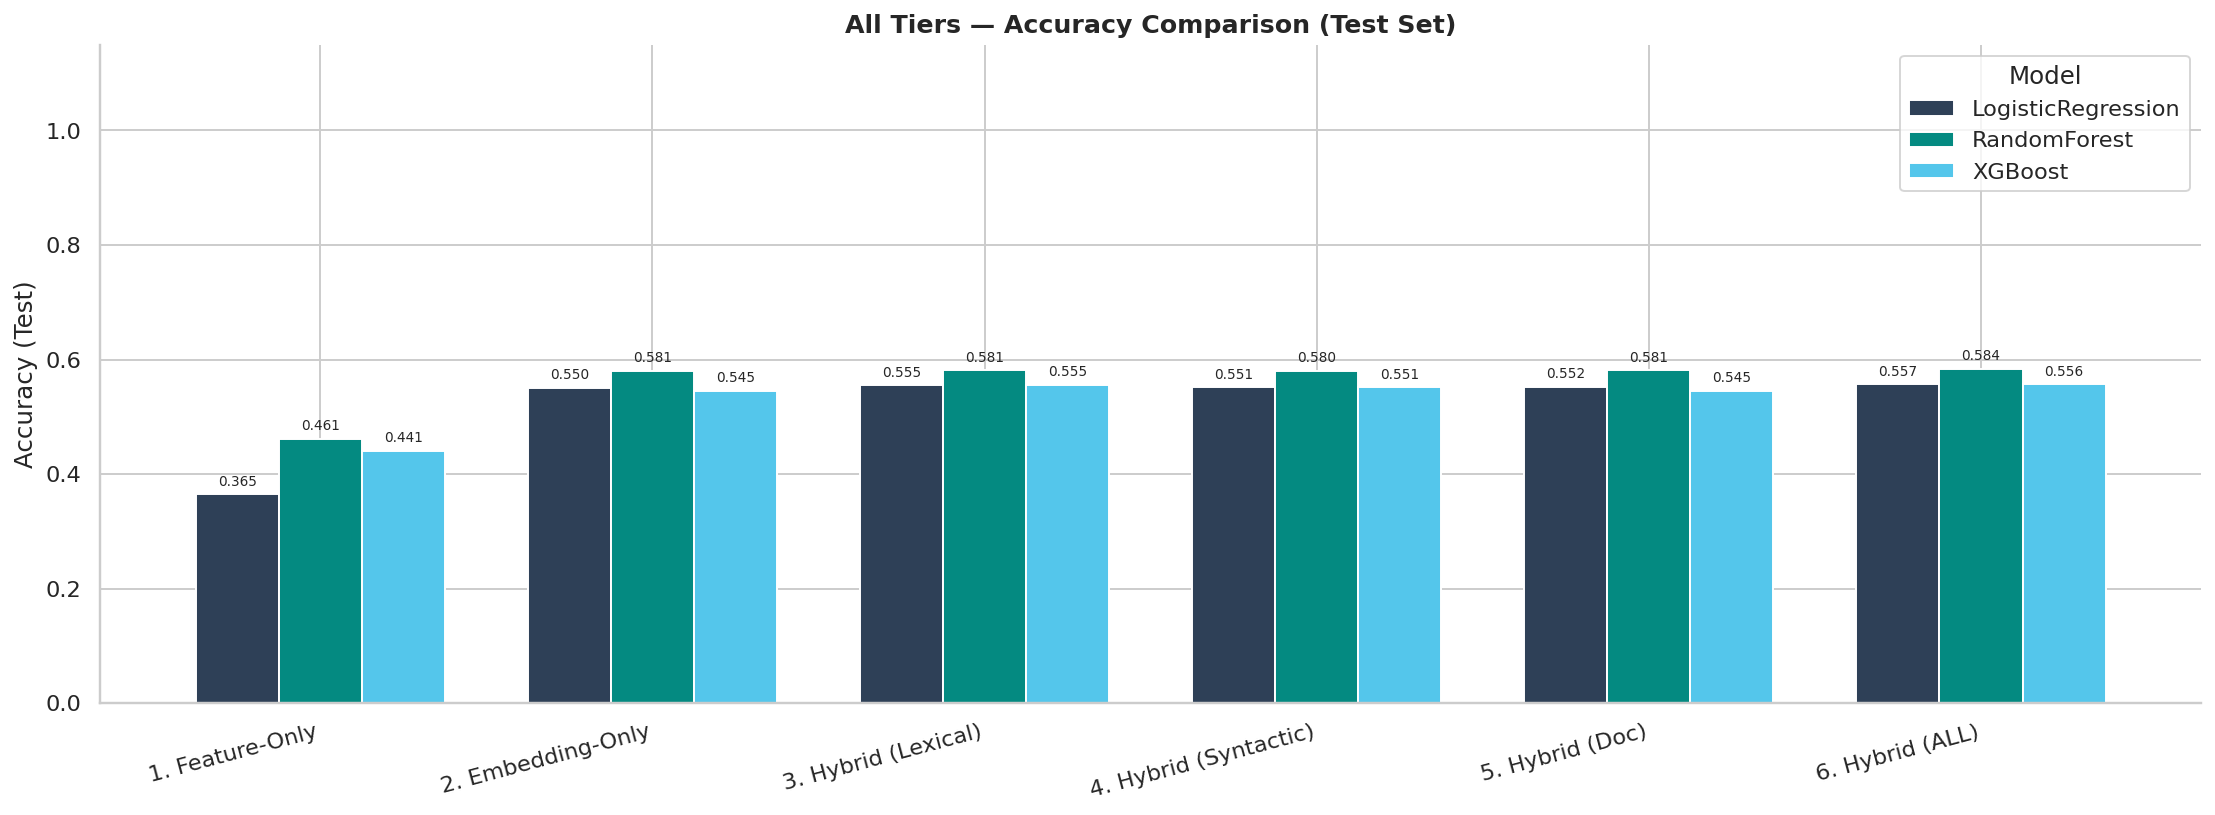

  saved -> /content/figures/comparison_accuracy.png


In [19]:
#Grouped bar: Accuracy — all tiers × all models
tier_names = list(TIERS.keys())
clf_names  = list(CLASSIFIERS.keys())
x = np.arange(len(tier_names)); w = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
for i, clf_name in enumerate(clf_names):
    vals = [df_res[(df_res["tier"]==t) & (df_res["model"]==clf_name)]["accuracy"].values[0]
            for t in tier_names]
    bars = ax.bar(x + i*w, vals, w, label=clf_name, color=PALETTE[i], edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)

ax.set_xticks(x + w)
ax.set_xticklabels(tier_names, rotation=15, ha="right")
ax.set_ylim(0, 1.15); ax.set_ylabel("Accuracy (Test)")
ax.set_title("All Tiers — Accuracy Comparison (Test Set)", fontweight="bold", fontsize=13)
ax.legend(title="Model")
plt.tight_layout()
savefig("comparison_accuracy.png")


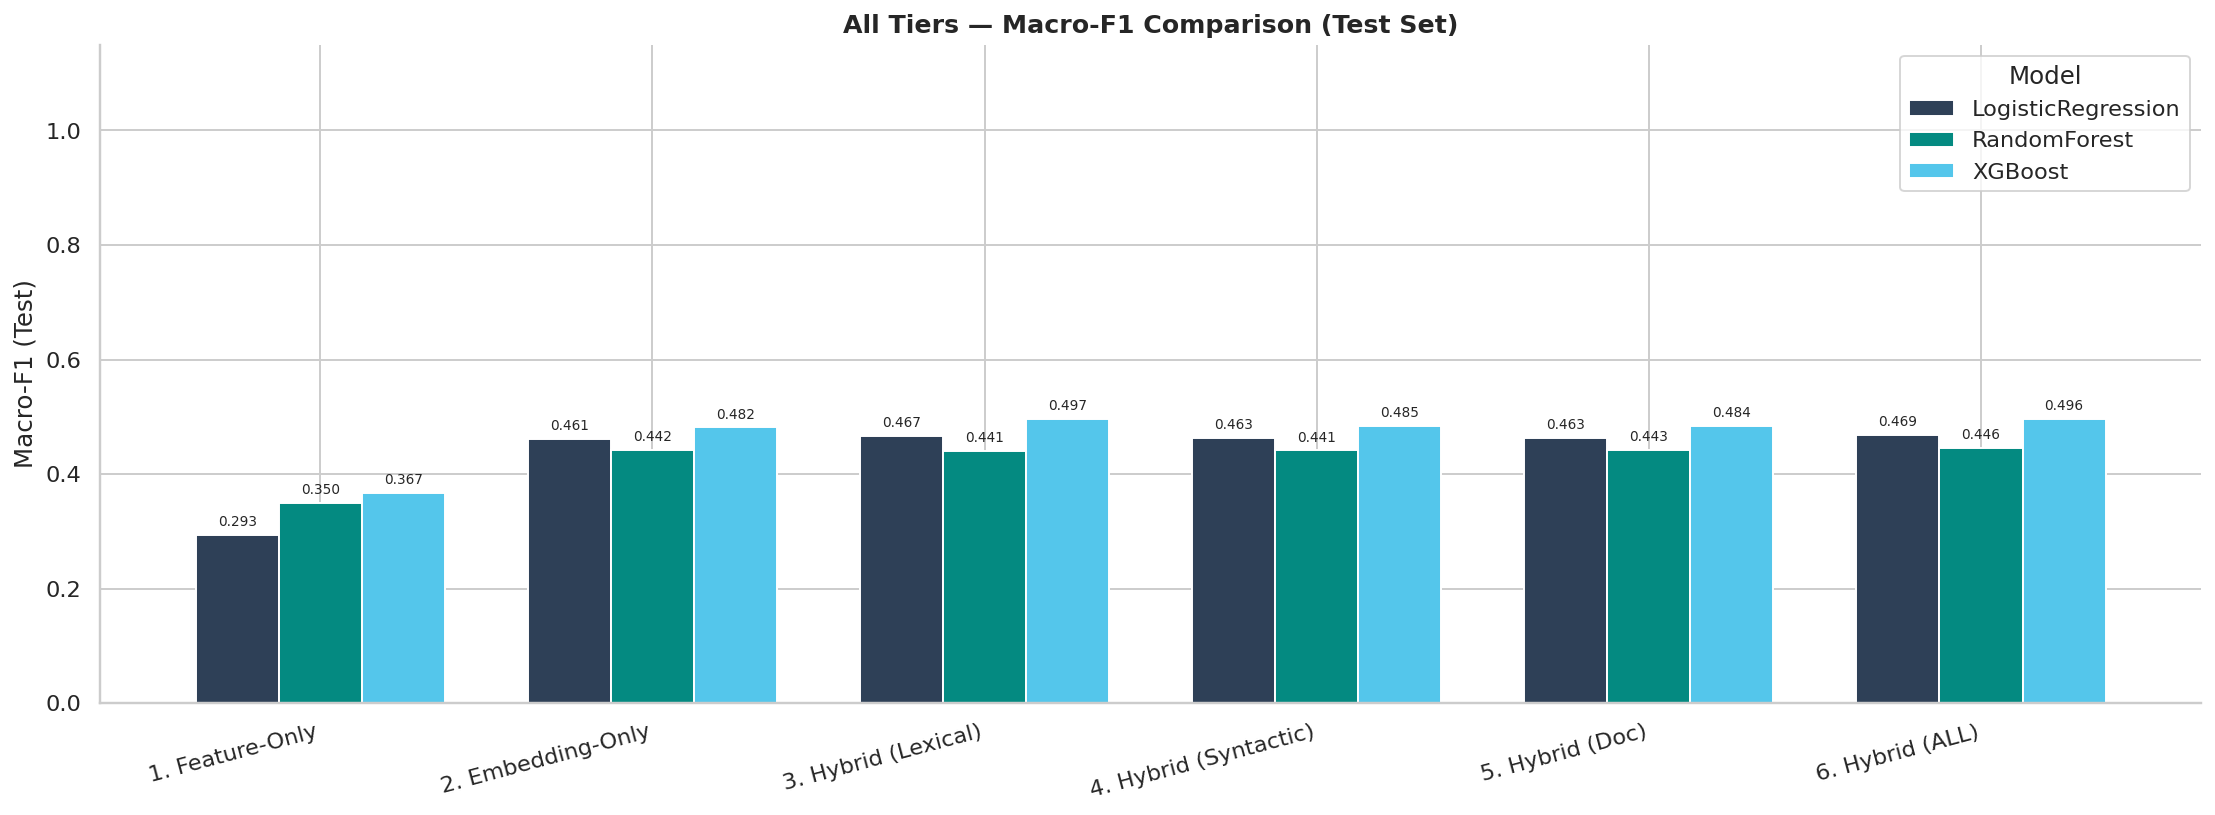

  saved -> /content/figures/comparison_macro_f1.png


In [20]:
#Grouped bar: Macro-F1 — all tiers × all models
fig, ax = plt.subplots(figsize=(16, 6))
for i, clf_name in enumerate(clf_names):
    vals = [df_res[(df_res["tier"]==t) & (df_res["model"]==clf_name)]["macro_f1"].values[0]
            for t in tier_names]
    bars = ax.bar(x + i*w, vals, w, label=clf_name, color=PALETTE[i], edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)

ax.set_xticks(x + w)
ax.set_xticklabels(tier_names, rotation=15, ha="right")
ax.set_ylim(0, 1.15); ax.set_ylabel("Macro-F1 (Test)")
ax.set_title("All Tiers — Macro-F1 Comparison (Test Set)", fontweight="bold", fontsize=13)
ax.legend(title="Model")
plt.tight_layout()
savefig("comparison_macro_f1.png")


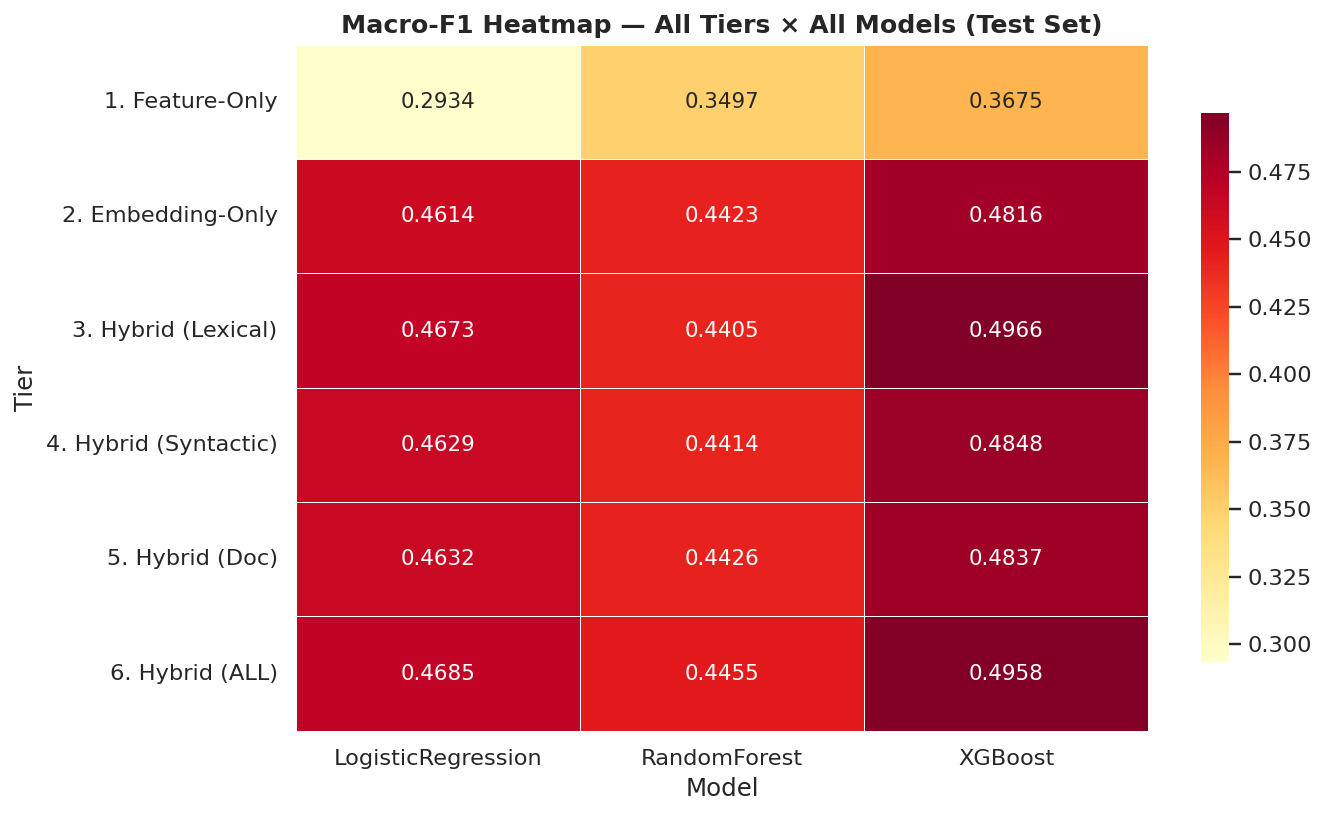

  saved -> /content/figures/heatmap_macro_f1.png


In [21]:
#Heatmap: Macro-F1 — tiers × models
heat_data = pd.DataFrame(
    {clf: [df_res[(df_res["tier"]==t) & (df_res["model"]==clf)]["macro_f1"].values[0]
           for t in tier_names]
     for clf in clf_names},
    index=tier_names
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=.5, ax=ax, cbar_kws={"shrink": .8},
            annot_kws={"size": 11})
ax.set_title("Macro-F1 Heatmap — All Tiers × All Models (Test Set)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Model"); ax.set_ylabel("Tier")
plt.tight_layout()
savefig("heatmap_macro_f1.png")


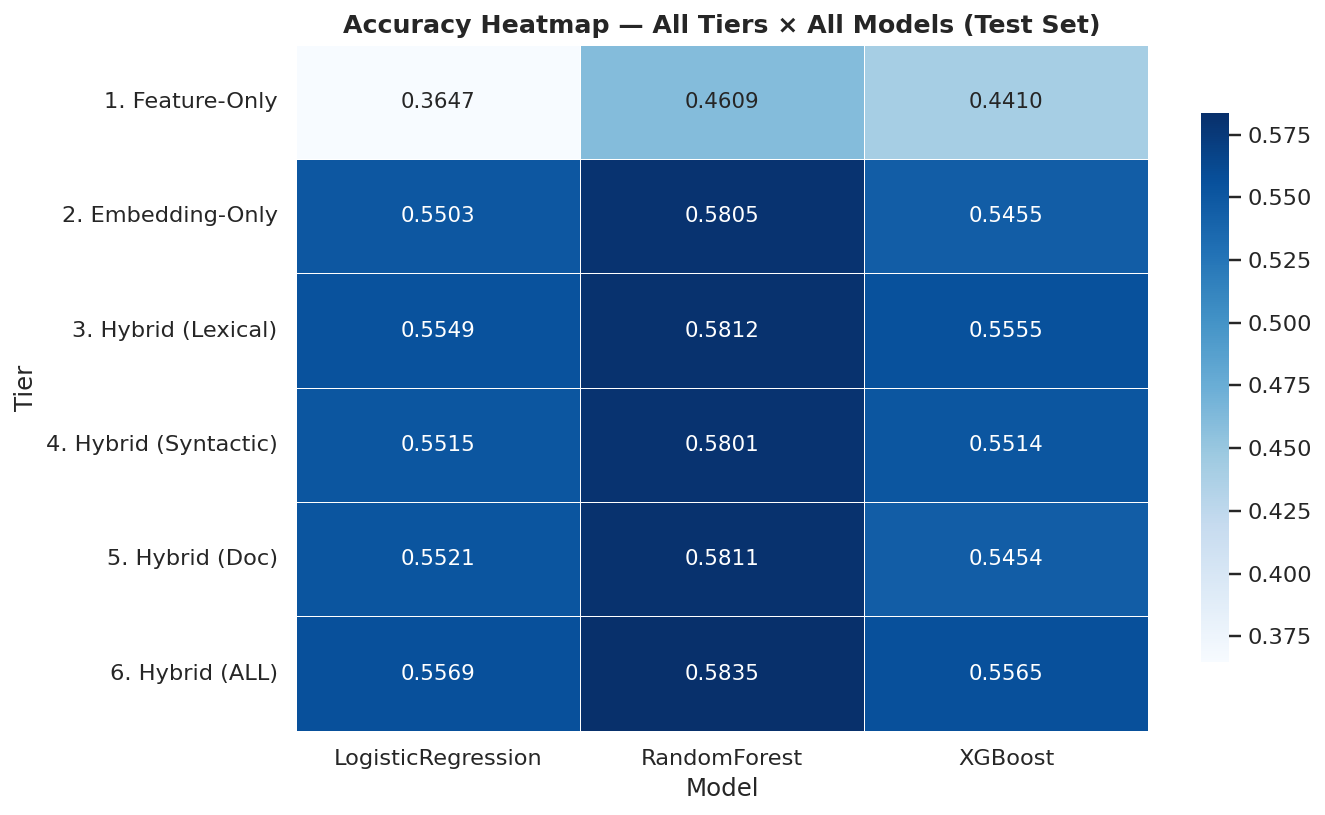

  saved -> /content/figures/heatmap_accuracy.png


In [22]:
#Heatmap: Accuracy — tiers × models
heat_acc = pd.DataFrame(
    {clf: [df_res[(df_res["tier"]==t) & (df_res["model"]==clf)]["accuracy"].values[0]
           for t in tier_names]
     for clf in clf_names},
    index=tier_names
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_acc, annot=True, fmt=".4f", cmap="Blues",
            linewidths=.5, ax=ax, cbar_kws={"shrink": .8},
            annot_kws={"size": 11})
ax.set_title("Accuracy Heatmap — All Tiers × All Models (Test Set)",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Model"); ax.set_ylabel("Tier")
plt.tight_layout()
savefig("heatmap_accuracy.png")


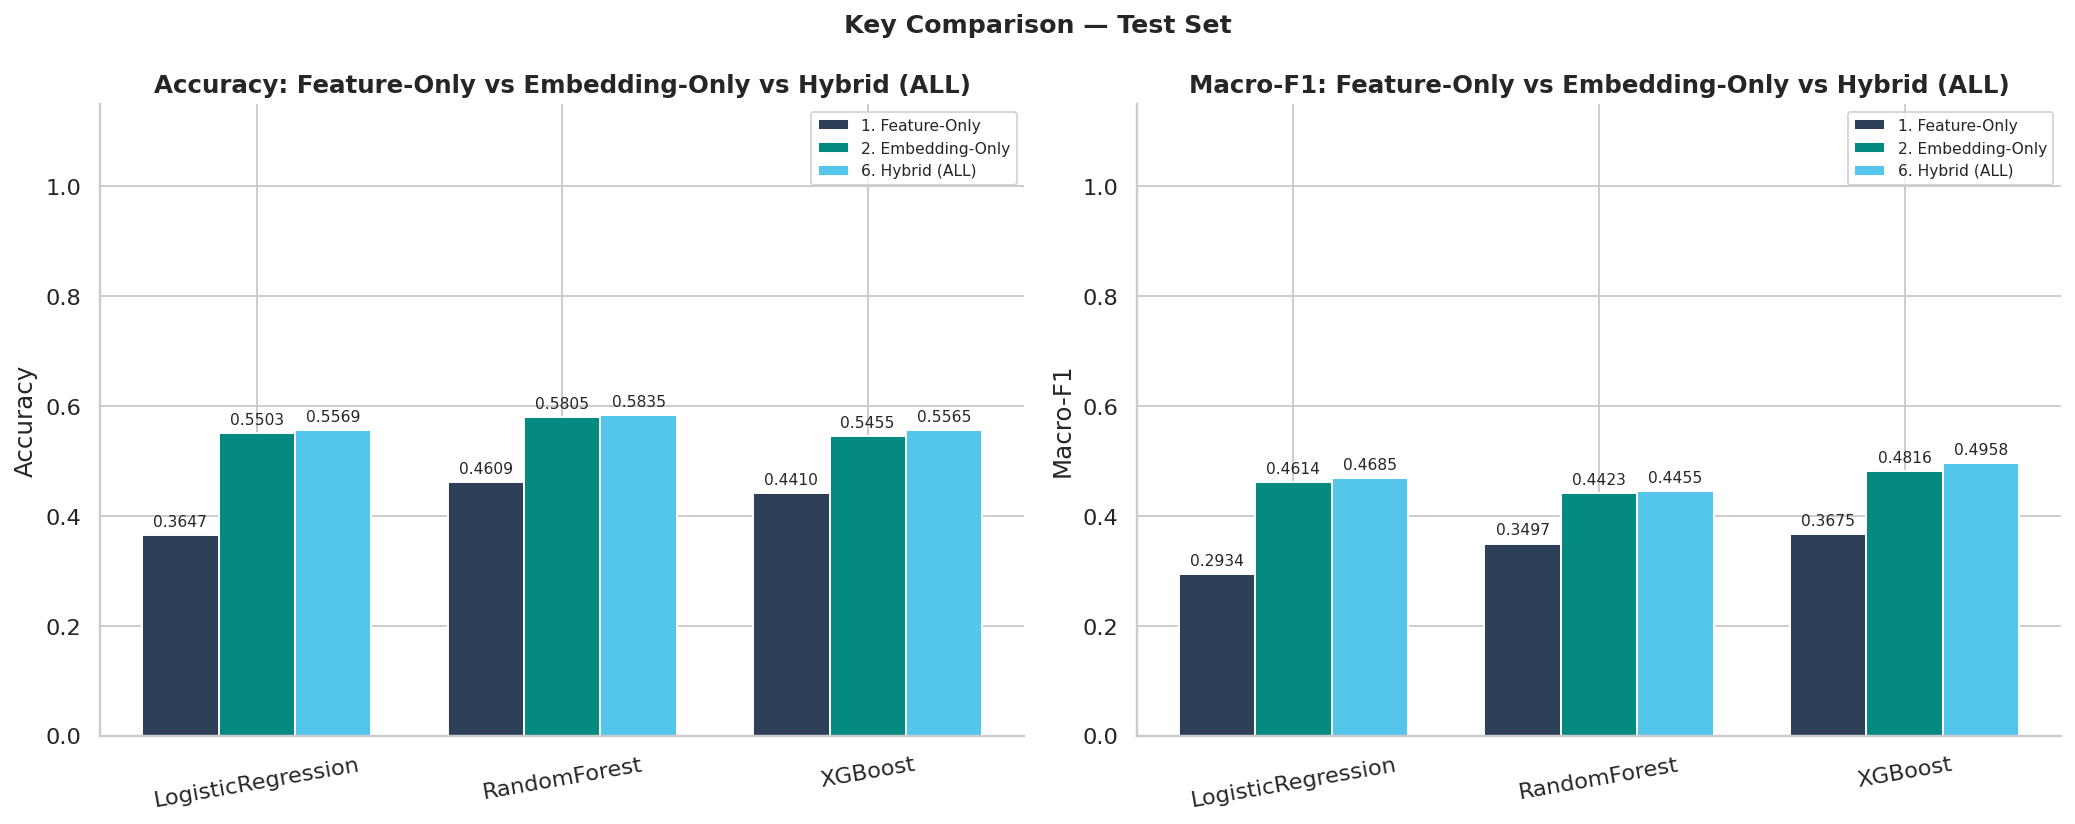

  saved -> /content/figures/key_comparison.png


In [23]:
#Feature-Only vs Embedding-Only vs Hybrid (ALL)
focus_tiers = ["1. Feature-Only", "2. Embedding-Only", "6. Hybrid (ALL)"]
fig, axes   = plt.subplots(1, 2, figsize=(15, 6))

for ax, metric, title in zip(axes, ["accuracy", "macro_f1"], ["Accuracy", "Macro-F1"]):
    x_f = np.arange(len(clf_names)); w_f = 0.25
    for i, tier in enumerate(focus_tiers):
        vals = [df_res[(df_res["tier"]==tier) & (df_res["model"]==c)][metric].values[0]
                for c in clf_names]
        bars = ax.bar(x_f + i*w_f, vals, w_f, label=tier,
                      color=PALETTE[i], edgecolor="white")
        ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=8)
    ax.set_xticks(x_f + w_f); ax.set_xticklabels(clf_names, rotation=10)
    ax.set_ylim(0, 1.15); ax.set_ylabel(title); ax.legend(fontsize=8)
    ax.set_title(f"{title}: Feature-Only vs Embedding-Only vs Hybrid (ALL)",
                 fontweight="bold")

plt.suptitle("Key Comparison — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
savefig("key_comparison.png")


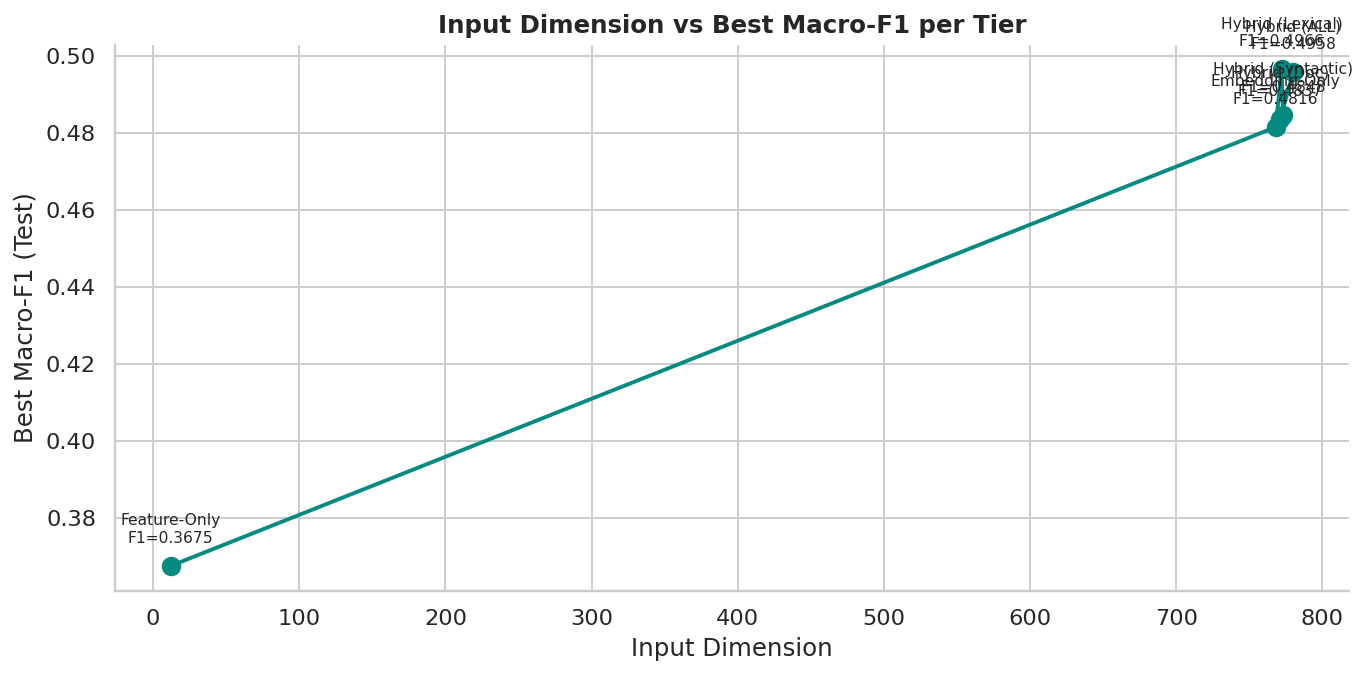

  saved -> /content/figures/dim_vs_f1.png


In [24]:
# Line chart: input dimension vs best macro-F1 per tier
best_per_tier = (df_res.groupby("tier")["macro_f1"]
                 .max()
                 .reindex(tier_names)
                 .reset_index())
best_per_tier["dim"] = best_per_tier["tier"].map(TIER_DIMS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(best_per_tier["dim"], best_per_tier["macro_f1"],
        marker="o", linewidth=2, markersize=9, color=PALETTE[1])
for _, row in best_per_tier.iterrows():
    ax.annotate(f"{row['tier'].split('. ')[1]}\nF1={row['macro_f1']:.4f}",
                (row["dim"], row["macro_f1"]),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=8)
ax.set_xlabel("Input Dimension"); ax.set_ylabel("Best Macro-F1 (Test)")
ax.set_title("Input Dimension vs Best Macro-F1 per Tier", fontweight="bold")
plt.tight_layout()
savefig("dim_vs_f1.png")


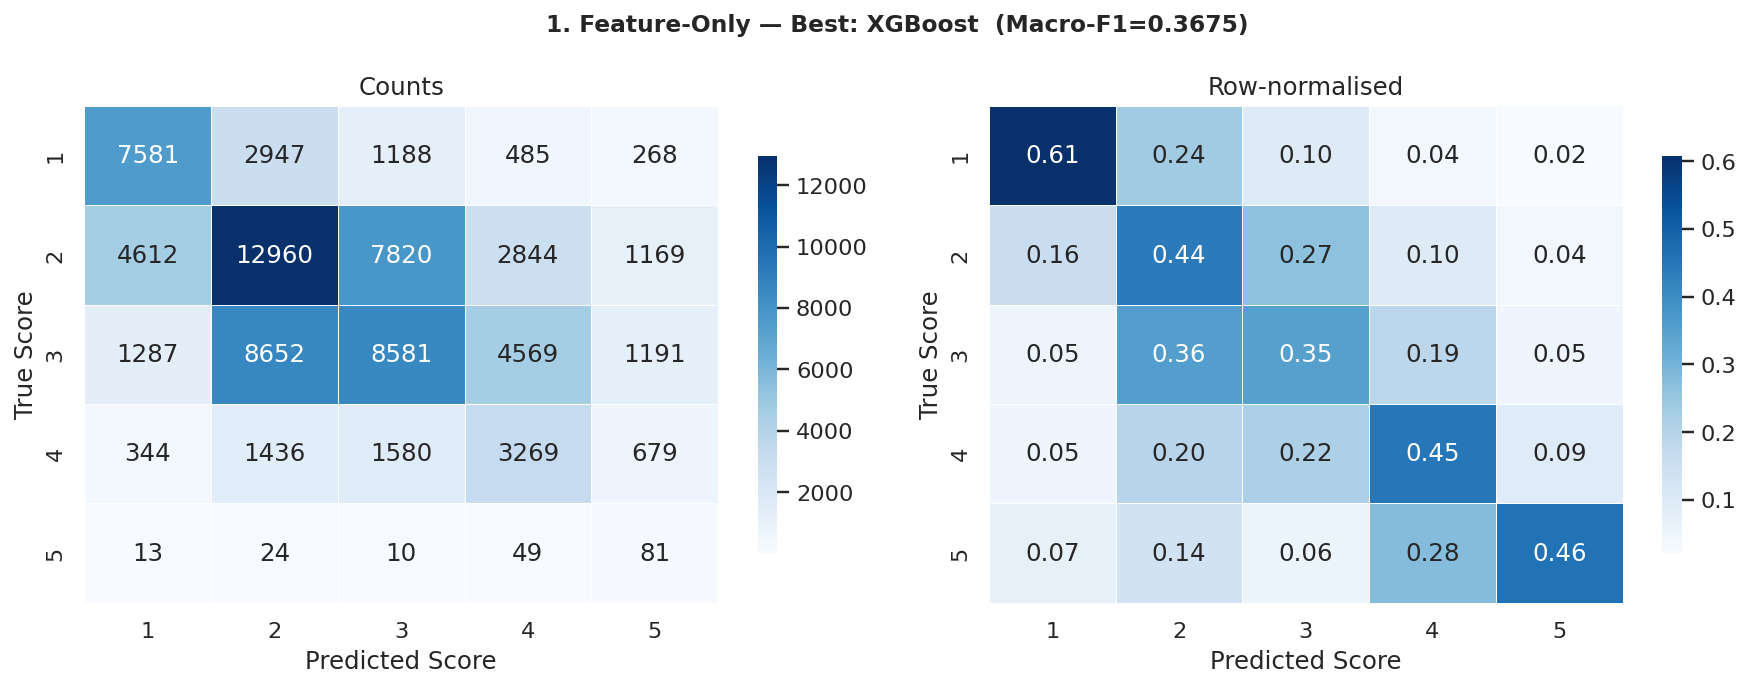

  saved -> /content/figures/cm_1_Feature-Only.png


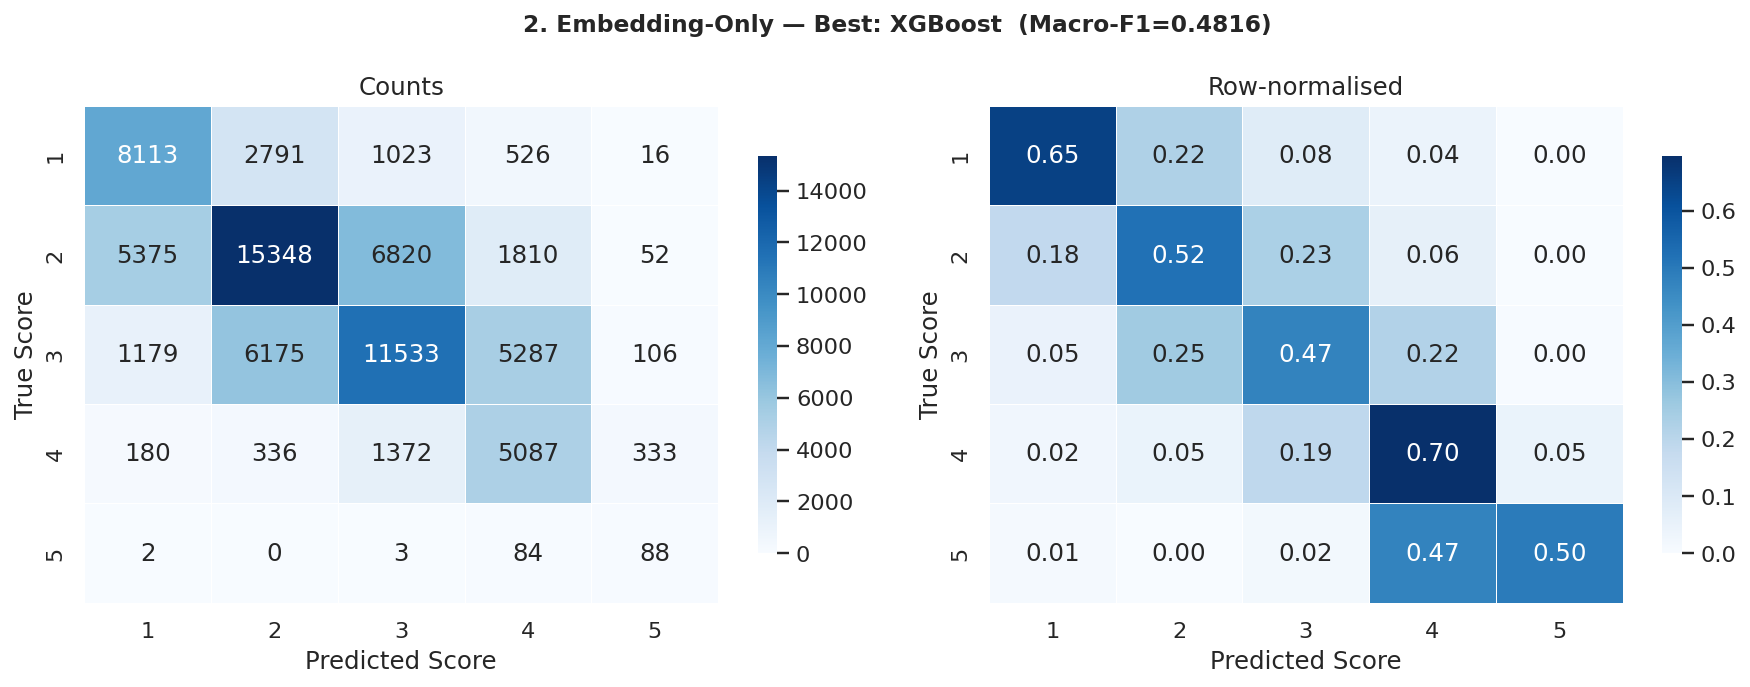

  saved -> /content/figures/cm_2_Embedding-Only.png


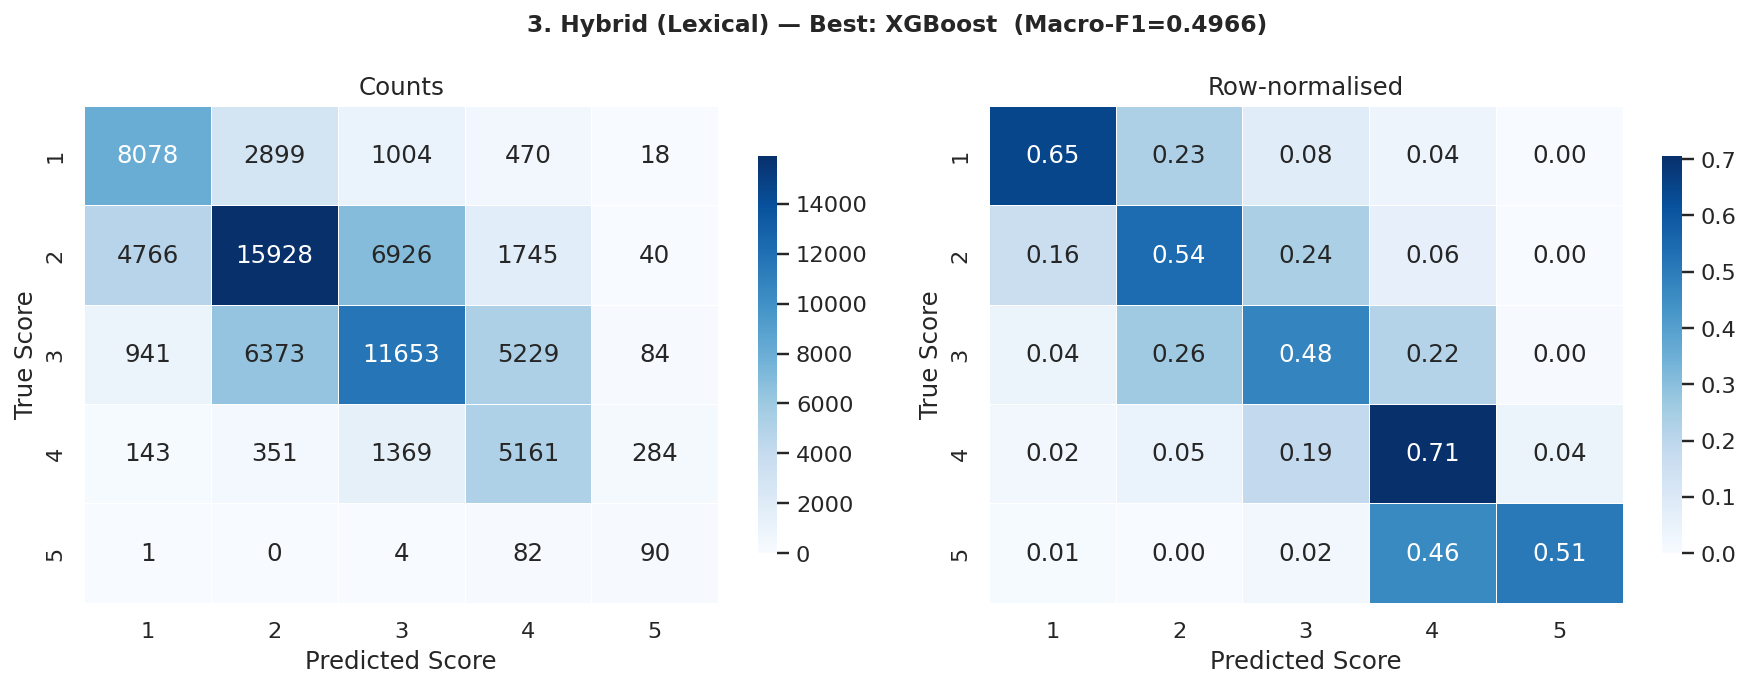

  saved -> /content/figures/cm_3_Hybrid_Lexical.png


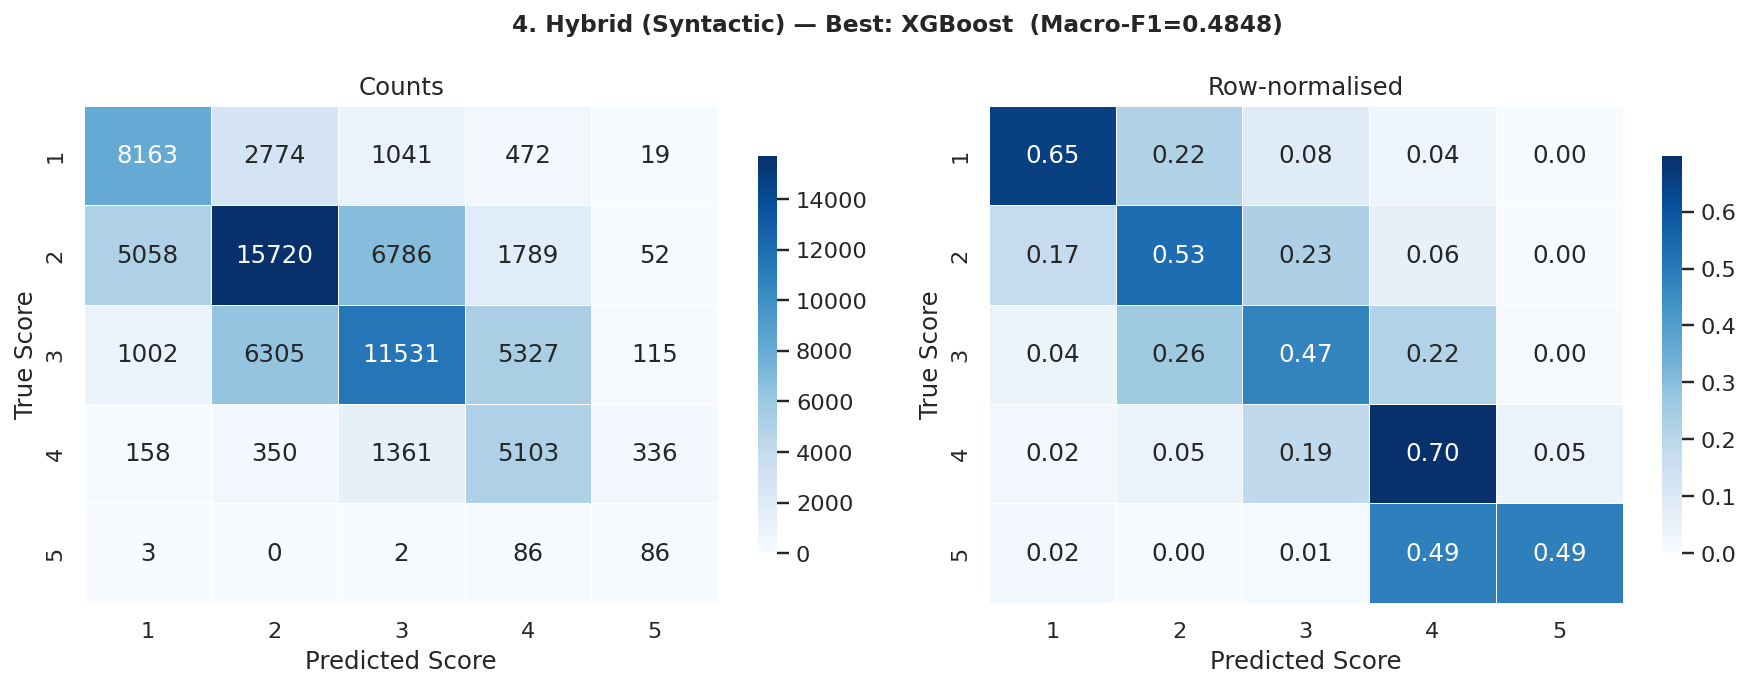

  saved -> /content/figures/cm_4_Hybrid_Syntactic.png


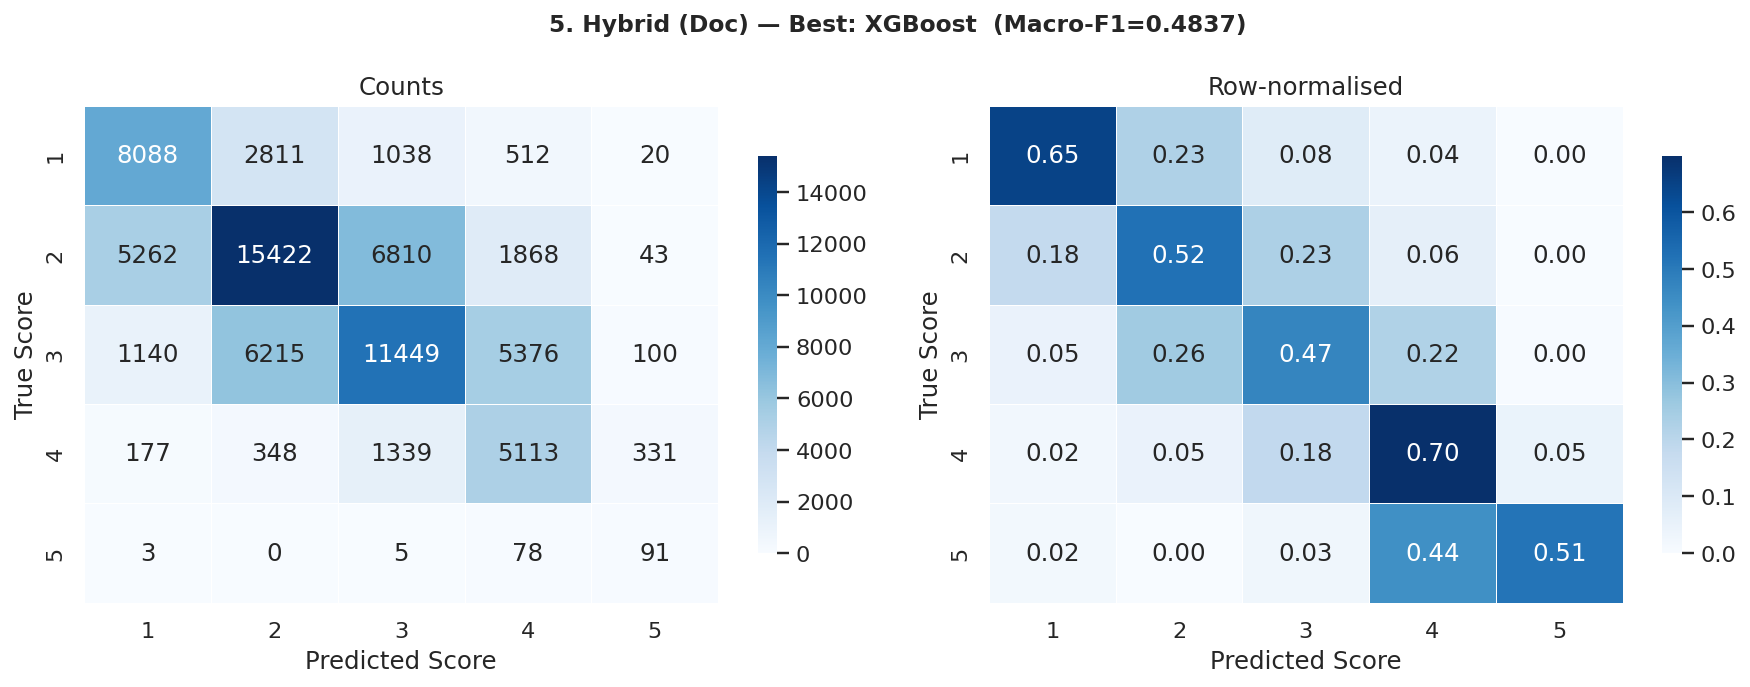

  saved -> /content/figures/cm_5_Hybrid_Doc.png


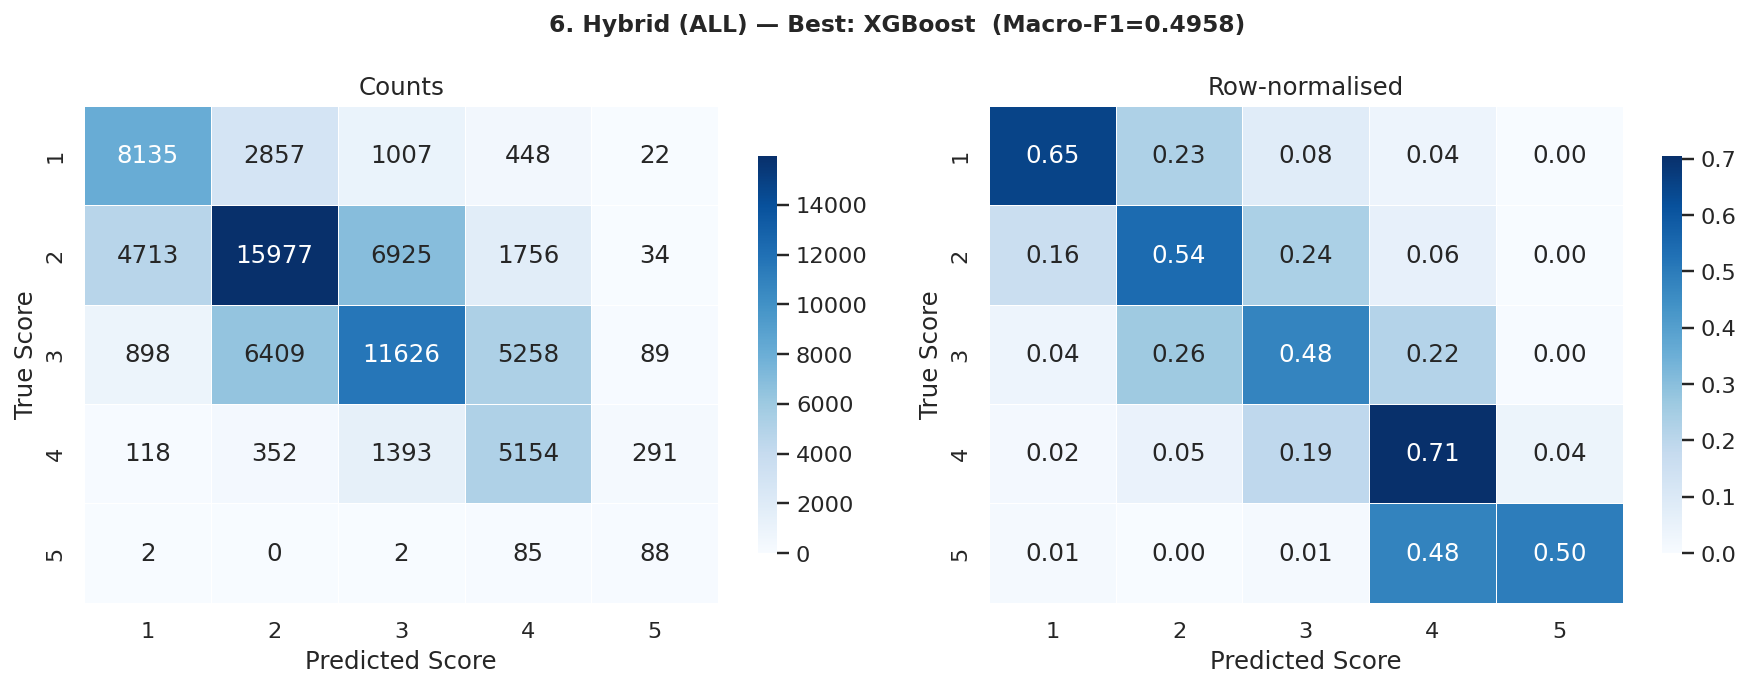

  saved -> /content/figures/cm_6_Hybrid_ALL.png


In [25]:
# Confusion matrices — best model per tier (all 6)
for tier_name in tier_names:
    best_row = df_res[df_res["tier"]==tier_name].sort_values("macro_f1", ascending=False).iloc[0]
    best_r   = next(r for r in all_tier_results
                    if r["tier"]==tier_name and r["model"]==best_row["model"])
    safe_name = tier_name.replace(" ","_").replace("(","").replace(")","").replace(".","")
    plot_cm(best_r["cm"],
            f"{tier_name} — Best: {best_row['model']}  (Macro-F1={best_row['macro_f1']:.4f})",
            f"cm_{safe_name}.png")


## 17. Delta Analysis

How much does each hybrid tier gain over Feature-Only and Embedding-Only?


In [26]:
delta_rows = []
for clf_name in clf_names:
    fo_f1  = df_res[(df_res["tier"]=="1. Feature-Only")    & (df_res["model"]==clf_name)]["macro_f1"].values[0]
    emb_f1 = df_res[(df_res["tier"]=="2. Embedding-Only")  & (df_res["model"]==clf_name)]["macro_f1"].values[0]
    for tier_name in tier_names[2:]:  # hybrid tiers only
        hyb_f1 = df_res[(df_res["tier"]==tier_name) & (df_res["model"]==clf_name)]["macro_f1"].values[0]
        delta_rows.append({
            "Model":              clf_name,
            "Tier":               tier_name,
            "Hybrid F1":          hyb_f1,
            "vs Feature-Only":    round(hyb_f1 - fo_f1,  4),
            "vs Embedding-Only":  round(hyb_f1 - emb_f1, 4),
        })

df_delta = pd.DataFrame(delta_rows)
print(df_delta.to_string(index=False))
print("\n(positive = hybrid wins, negative = baseline wins)")


             Model                  Tier  Hybrid F1  vs Feature-Only  vs Embedding-Only
LogisticRegression   3. Hybrid (Lexical)     0.4673           0.1739             0.0059
LogisticRegression 4. Hybrid (Syntactic)     0.4629           0.1695             0.0015
LogisticRegression       5. Hybrid (Doc)     0.4632           0.1698             0.0018
LogisticRegression       6. Hybrid (ALL)     0.4685           0.1751             0.0071
      RandomForest   3. Hybrid (Lexical)     0.4405           0.0908            -0.0018
      RandomForest 4. Hybrid (Syntactic)     0.4414           0.0917            -0.0009
      RandomForest       5. Hybrid (Doc)     0.4426           0.0929             0.0003
      RandomForest       6. Hybrid (ALL)     0.4455           0.0958             0.0032
           XGBoost   3. Hybrid (Lexical)     0.4966           0.1291             0.0150
           XGBoost 4. Hybrid (Syntactic)     0.4848           0.1173             0.0032
           XGBoost       5. Hybr

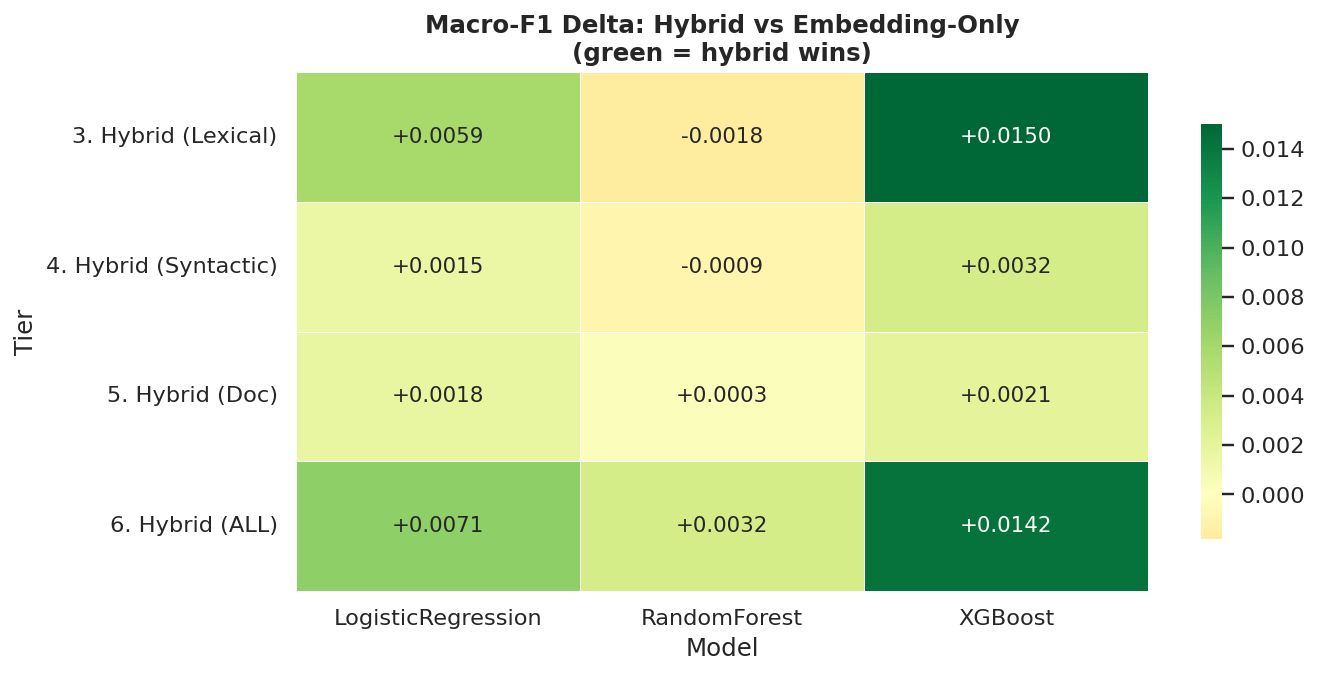

  saved -> /content/figures/delta_heatmap.png


In [27]:
# Delta heatmap — Hybrid vs Embedding-Only, by model
delta_pivot = df_delta.pivot_table(
    index="Tier", columns="Model", values="vs Embedding-Only", aggfunc="first"
).reindex(tier_names[2:])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(delta_pivot, annot=True, fmt="+.4f", cmap="RdYlGn",
            center=0, linewidths=.5, ax=ax,
            cbar_kws={"shrink": .8}, annot_kws={"size": 11})
ax.set_title("Macro-F1 Delta: Hybrid vs Embedding-Only\n(green = hybrid wins)",
             fontweight="bold")
plt.tight_layout()
savefig("delta_heatmap.png")


## 18. Master Summary Table

Saved -> /content/results/file4_results.csv


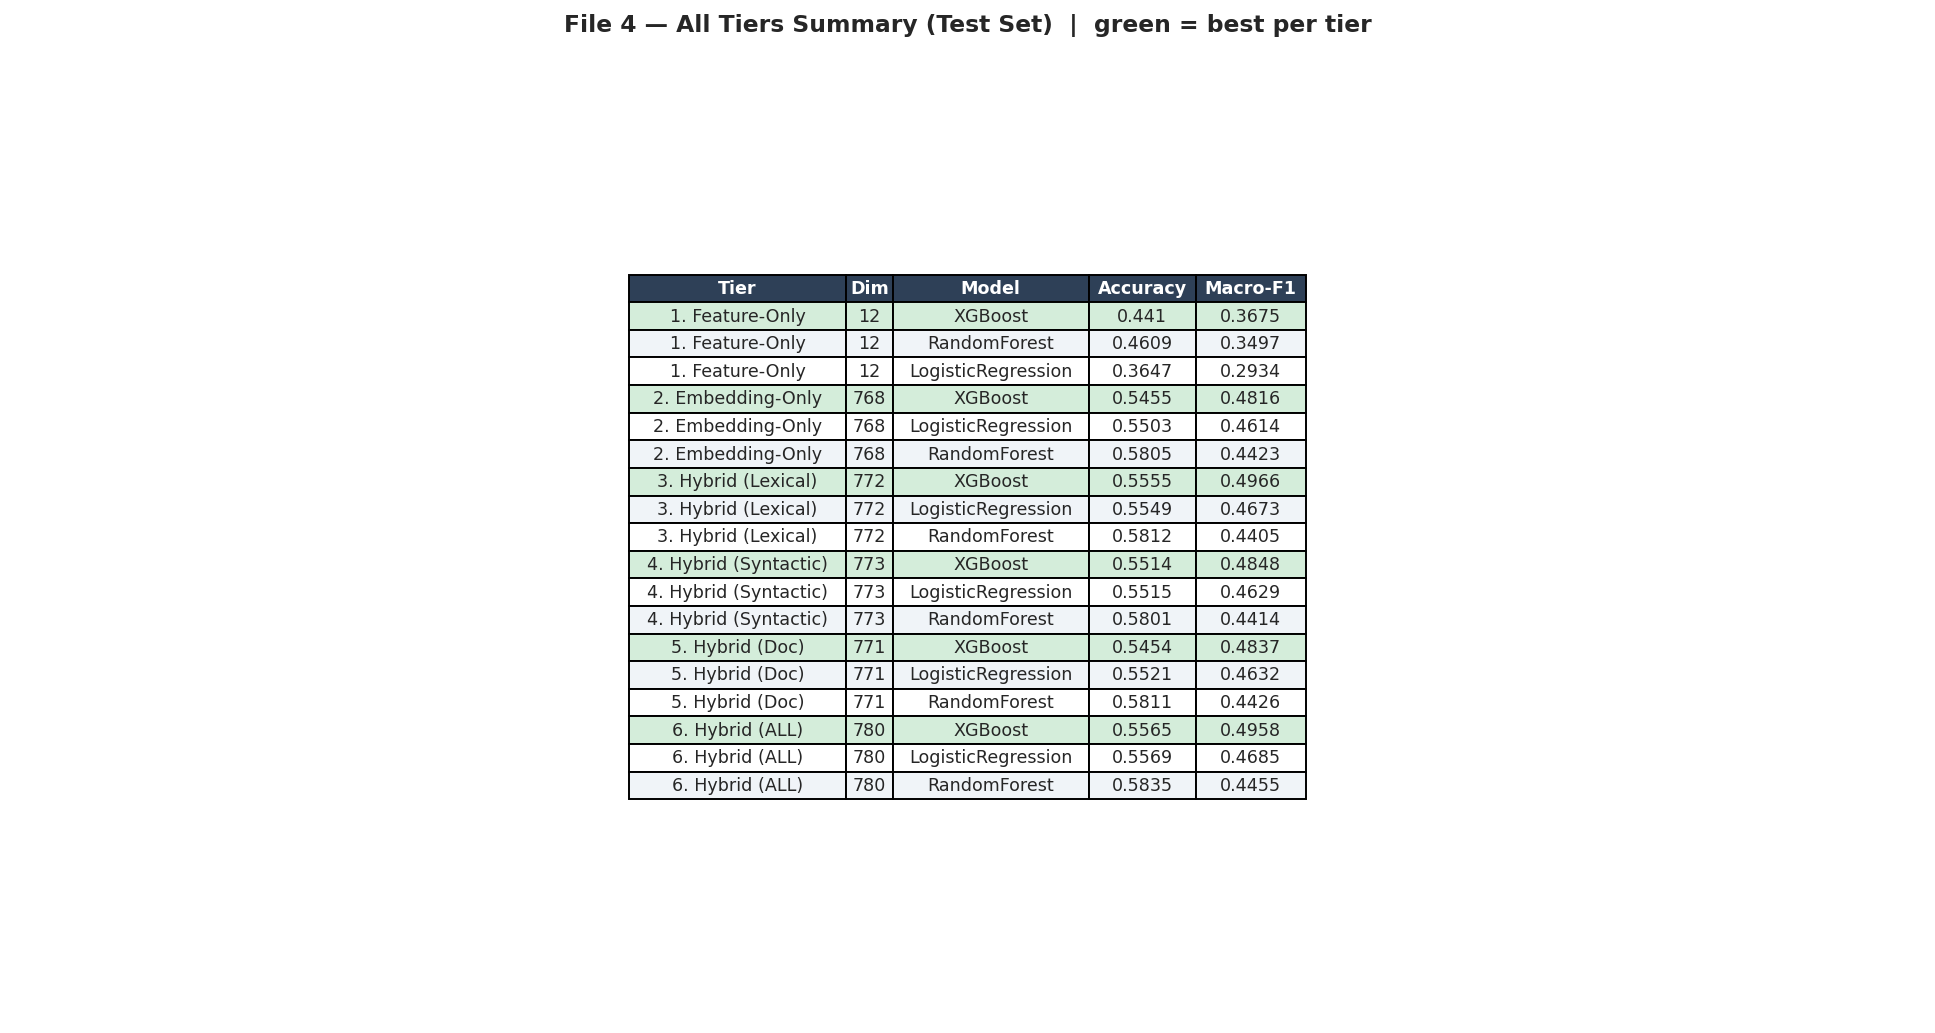

  saved -> /content/figures/final_summary_table.png
MASTER SUMMARY
                 Tier  Dim              Model  Accuracy  Macro-F1
      1. Feature-Only   12            XGBoost    0.4410    0.3675
      1. Feature-Only   12       RandomForest    0.4609    0.3497
      1. Feature-Only   12 LogisticRegression    0.3647    0.2934
    2. Embedding-Only  768            XGBoost    0.5455    0.4816
    2. Embedding-Only  768 LogisticRegression    0.5503    0.4614
    2. Embedding-Only  768       RandomForest    0.5805    0.4423
  3. Hybrid (Lexical)  772            XGBoost    0.5555    0.4966
  3. Hybrid (Lexical)  772 LogisticRegression    0.5549    0.4673
  3. Hybrid (Lexical)  772       RandomForest    0.5812    0.4405
4. Hybrid (Syntactic)  773            XGBoost    0.5514    0.4848
4. Hybrid (Syntactic)  773 LogisticRegression    0.5515    0.4629
4. Hybrid (Syntactic)  773       RandomForest    0.5801    0.4414
      5. Hybrid (Doc)  771            XGBoost    0.5454    0.4837
      5. 

In [28]:
summary_rows = []
for r in all_tier_results:
    summary_rows.append({
        "Tier":       r["tier"],
        "Dim":        r["dim"],
        "Model":      r["model"],
        "Accuracy":   r["accuracy"],
        "Macro-F1":   r["macro_f1"],
    })

df_summary = pd.DataFrame(summary_rows).sort_values(
    ["Tier", "Macro-F1"], ascending=[True, False]
)

csv_path = os.path.join(RSLTS, "file4_results.csv")
df_summary.to_csv(csv_path, index=False)
print(f"Saved -> {csv_path}")

fig, ax = plt.subplots(figsize=(14, max(6, len(df_summary)*0.42)))
ax.axis("off")
tbl = ax.table(cellText=df_summary.values, colLabels=df_summary.columns,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(range(len(df_summary.columns)))
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#F0F4F8")
    # highlight best row per tier
    if r > 0:
        tier_val = df_summary.iloc[r-1]["Tier"]
        best_f1  = df_summary[df_summary["Tier"]==tier_val]["Macro-F1"].max()
        if df_summary.iloc[r-1]["Macro-F1"] == best_f1:
            cell.set_facecolor("#D4EDDA")
ax.set_title("File 4 — All Tiers Summary (Test Set)  |  green = best per tier",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
savefig("final_summary_table.png")

print("=" * 70)
print("MASTER SUMMARY")
print("=" * 70)
print(df_summary.to_string(index=False))
print(f"\nFigures -> {FIGS}/")
print(f"Results -> {RSLTS}/")
